# Wald Solution — Verification (split-IMR)

Reproduces Bacchini et al. 2019 Figures 1–2 for orbit **RKA3** (Table 1).  
Uses `geodesics_IMR_split` (operator-split IMR) vs `geodesics_RK4`.

In [17]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve() / 'out'))
import Kerr_geodesics as kgeo
import util

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [18]:
# Orbit RKA3 — Table 1 of Bacchini 2019
M, a     = 1.0, 0.9
B_z, B_x = 2.0, 0.0
Q_BH     = 0.0
q_over_m = 1.0

r0, th0, phi0   = 4.0, np.pi/2 - 0.2, 0.0
ur0, uth0, uph0 = 0.0, 0.0, 1.565

dt        = 1.0
t_end     = 2000.0
max_steps = int(t_end / dt) + 10
domain_L  = 20.0

ic = kgeo.IC(r0, th0, phi0, ur0, uth0, uph0, eps=1, q_over_m=q_over_m)

geos_RK4, _ = kgeo.geodesics_RK4(
    M, a, dt, max_steps, domain_L, 1e-5, 1e-6,
    em_field='wald', B_z=B_z, B_x=B_x, Q_charge=Q_BH, ics=[ic]
)
geos_IMR, _ = kgeo.geodesics_IMR_split(
    M, a, dt, max_steps, 120, domain_L, 1e-5, 1e-6,
    em_field='wald', B_z=B_z, B_x=B_x, Q_charge=Q_BH, ics=[ic]
)

geos_IMR_unsplit, _ = kgeo.geodesics_IMR(
    M, a, dt, max_steps, 120, domain_L, 1e-5, 1e-6,
    em_field='wald', B_z=B_z, B_x=B_x, Q_charge=Q_BH, ics=[ic]
)

geo_RK4 = np.array(geos_RK4[0])   # shape (N, 3): r, th, phi
geo_IMR = np.array(geos_IMR[0])
geo_IMR_unsplit = np.array(geos_IMR_unsplit[0])

def to_car(geo):
    return util.sph_to_Car(geo[:,0], geo[:,1], geo[:,2])

def to_poloidal(geo):
    """rho = r*sin(th), z = r*cos(th)"""
    r, th = geo[:,0], geo[:,1]
    return r*np.sin(th), r*np.cos(th)

print('Done.')

Done.


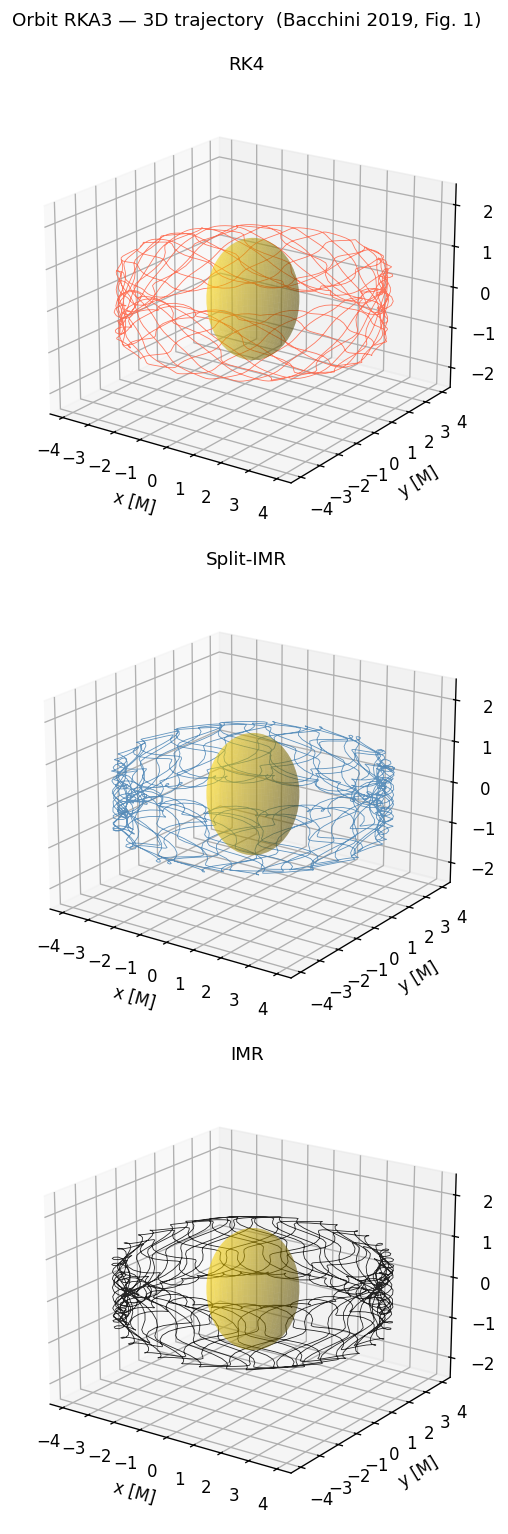

In [19]:
# Figure 1 — 3D trajectories
r_plus = M + np.sqrt(M**2 - a**2)

u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 30)
bh_x = r_plus * np.outer(np.cos(u), np.sin(v))
bh_y = r_plus * np.outer(np.sin(u), np.sin(v))
bh_z = r_plus * np.outer(np.ones(50), np.cos(v))

fig, axes = plt.subplots(3, 1, figsize=(6, 13),
                          subplot_kw={'projection': '3d'})

for ax, geo, color, label in [
    (axes[0], geo_RK4, 'tomato',    'RK4'),
    (axes[1], geo_IMR, 'steelblue', 'Split-IMR'),
    (axes[2], geo_IMR_unsplit, 'black', 'IMR'),
]:
    X, Y, Z = to_car(geo)
    ax.plot(X, Y, Z, color=color, lw=0.5, alpha=0.85)
    ax.plot_surface(bh_x, bh_y, bh_z, color='gold', alpha=0.35, linewidth=0)
    ax.set_xlabel('x [M]'); ax.set_ylabel('y [M]'); ax.set_zlabel('z [M]')
    ax.set_title(label, fontsize=11)
    ax.set_xlim3d(-4.5, 4.5); ax.set_ylim3d(-4.5, 4.5); ax.set_zlim3d(-2.5, 2.5)
    ax.view_init(elev=20, azim=-55)

plt.suptitle('Orbit RKA3 — 3D trajectory  (Bacchini 2019, Fig. 1)\n', fontsize=11)
plt.tight_layout()
plt.savefig('out/WaldV2_RKA3_3d.png', dpi=150, bbox_inches='tight')
plt.show()

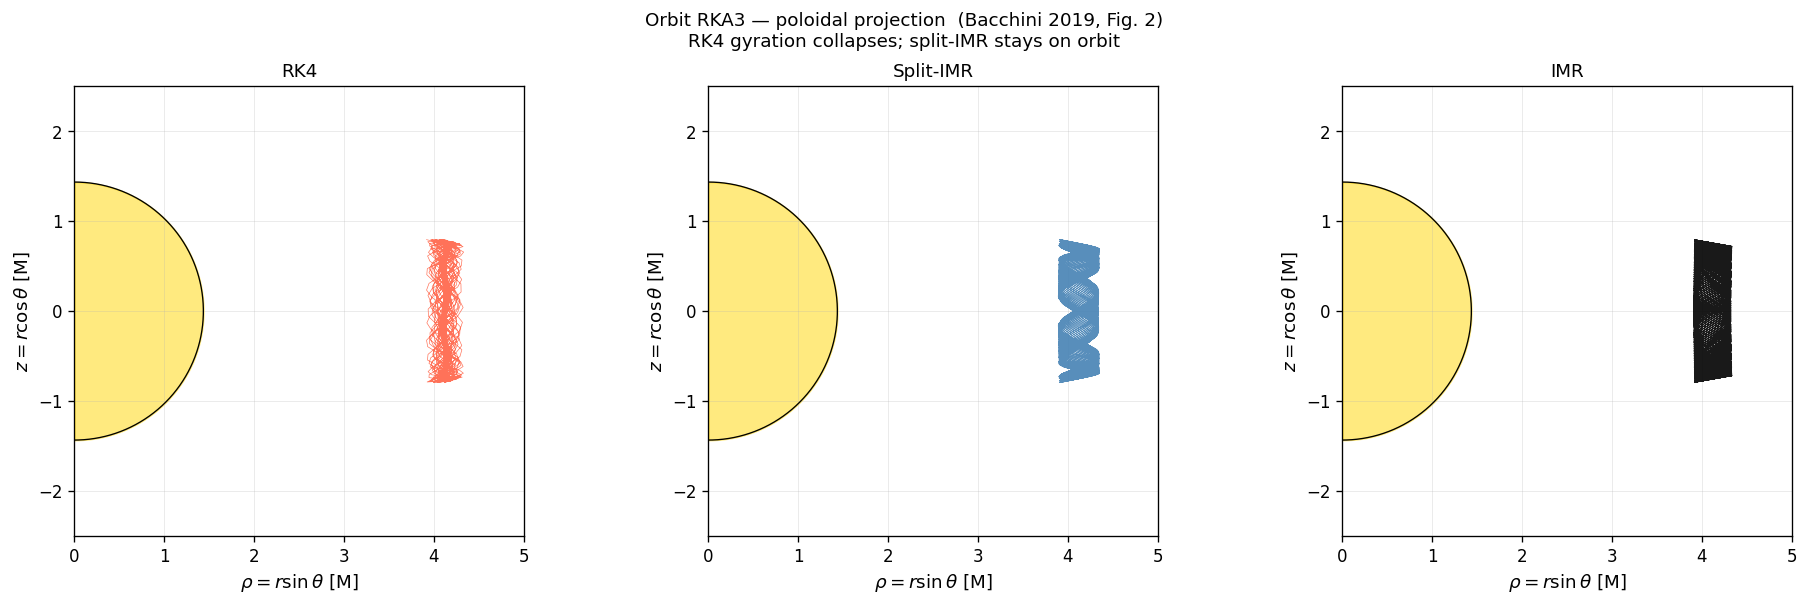

In [20]:
# Figure 2 — poloidal projection (rho, z) = (r*sin(th), r*cos(th))
th_bh = np.linspace(0, np.pi, 300)
bh_rho = r_plus * np.sin(th_bh)
bh_z   = r_plus * np.cos(th_bh)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, geo, color, label in [
    (axes[0], geo_RK4, 'tomato',    'RK4'),
    (axes[1], geo_IMR, 'steelblue', 'Split-IMR'),
    (axes[2], geo_IMR_unsplit, 'black', 'IMR'),
]:
    rho, z = to_poloidal(geo)
    ax.plot(rho, z, color=color, lw=0.4, alpha=0.9)
    ax.fill_betweenx(bh_z, 0, bh_rho, color='gold', alpha=0.5)
    ax.plot(bh_rho, bh_z, 'k-', lw=0.8)
    ax.set_xlabel(r'$\rho = r\sin\theta$ [M]', fontsize=11)
    ax.set_ylabel(r'$z = r\cos\theta$ [M]', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, lw=0.3, alpha=0.5)

plt.suptitle('Orbit RKA3 — poloidal projection  (Bacchini 2019, Fig. 2)\n'
             'RK4 gyration collapses; split-IMR stays on orbit', fontsize=11)
plt.tight_layout()
plt.savefig('out/WaldV2_RKA3_poloidal.png', dpi=150, bbox_inches='tight')
plt.show()

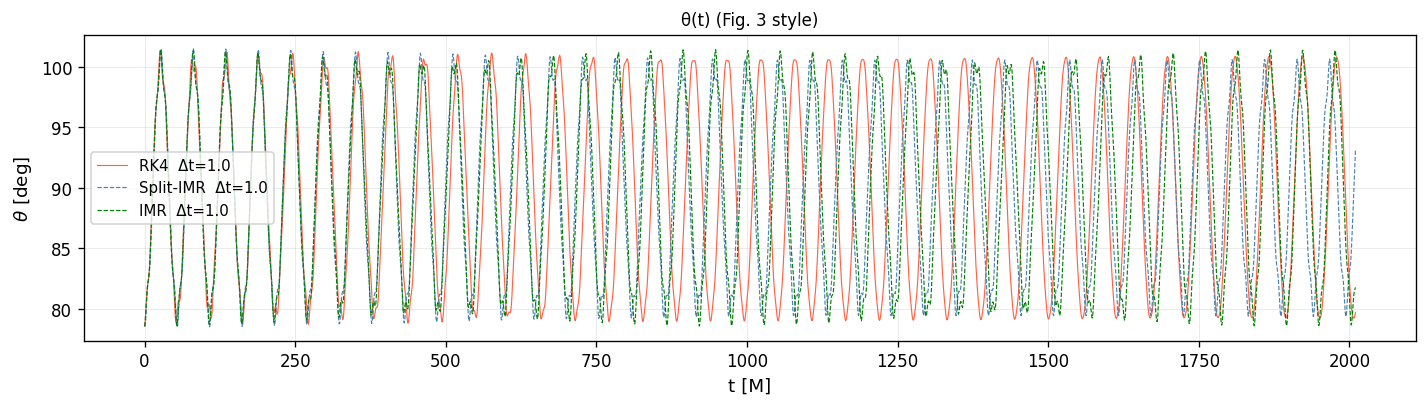

In [21]:
# theta(t) — gyration amplitude decay visible for RK4
t = np.arange(len(geo_RK4)) * dt

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, np.degrees(geo_RK4[:, 1]), color='tomato',    lw=0.7, label=f'RK4  Δt={dt}')
ax.plot(t, np.degrees(geo_IMR[:, 1]), color='steelblue', lw=0.7, ls='--', label=f'Split-IMR  Δt={dt}')
ax.plot(t, np.degrees(geo_IMR_unsplit[:, 1]), color='green', lw=0.7, ls='--', label=f'IMR  Δt={dt}')
ax.set_xlabel('t [M]', fontsize=11)
ax.set_ylabel(r'$\theta$ [deg]', fontsize=11)
ax.legend(fontsize=9)
ax.set_title('θ(t) (Fig. 3 style)', fontsize=10)
ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()
plt.savefig('out/WaldV2_RKA3_theta.png', dpi=150, bbox_inches='tight')
plt.show()